In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data1.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [4]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [5]:
df["Дата"] = pd.to_datetime(df["Дата"])

In [6]:
df.dtypes

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object

Сгруппируйте данные по дате, посчитайте количество продаж

In [8]:
grouped_df = df.groupby("Дата").size().reset_index(name="Количество продаж")

Вывести несколько первых строк сгруппированных данных

In [9]:
grouped_df.head()

,Дата,Количество продаж
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


Нарисуйте график продаж у `grouped_df`

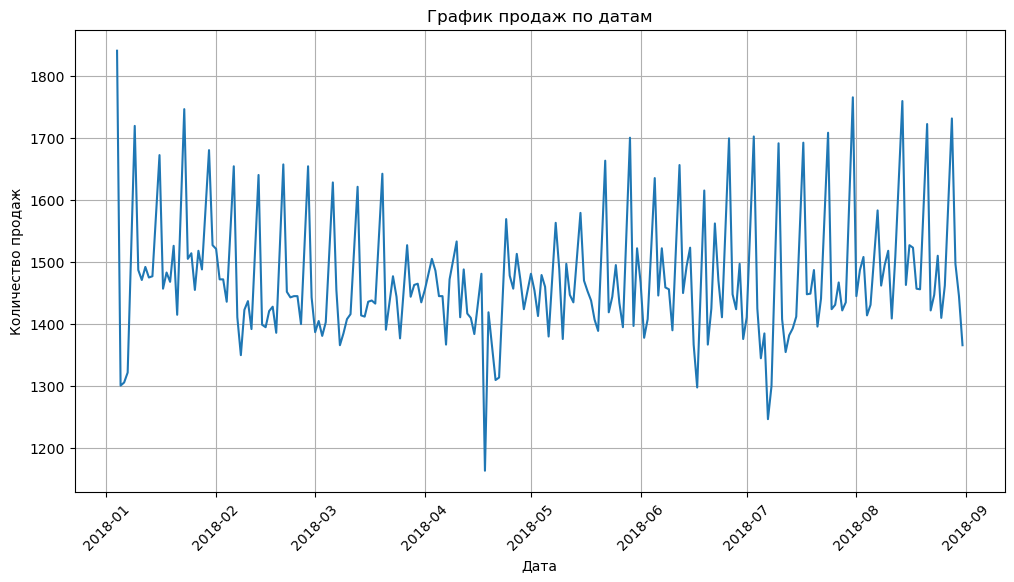

In [10]:
plt.figure(figsize=(12,6))

plt.plot(grouped_df["Дата"], grouped_df["Количество продаж"])

plt.title("График продаж по датам")
plt.xlabel("Дата")
plt.ylabel("Количество продаж")

plt.xticks(rotation=45)
plt.grid()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
График продаж охватывает период с января по сентябрь 2018 года. Согласно данному графику мы видим, что в основном количество продаж 
в течении периода варьируются от 1350 до 1700, но также наблюдаются всплески по увеличению продаж в январе до 1850 и уменьшению в период апреля-май, где 
наименьший показаль продаж опустился до 600.


Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [11]:
df[df["Количество"] == df["Количество"].max()]

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [13]:
df["Дата"] = pd.to_datetime(df["Дата"])

In [14]:
df["День недели"] = df["Дата"].dt.day_name()
df["Месяц"] = df["Дата"].dt.month

In [15]:
filtered = df[
    (df["День недели"] == "Wednesday") &
    (df["Месяц"].isin([6, 7, 8])) &
    (df["Склад"].isin([1, 2, 3]))
]

In [17]:
top_product = (
    filtered.groupby("Номенклатура")["Количество"]
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

In [18]:
top_product

Номенклатура
product_1    8135
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [74]:
weather_df["Дата"] = pd.to_datetime(weather_df["Дата"])

In [97]:
import pandas as pd

In [98]:
weather_df["Дата"] = pd.to_datetime(weather_df["Дата"])

KeyError: 'Дата'

In [99]:
weather_df = pd.read_csv(
    r"C:\Users\user\Desktop\Phyton\weather_dff.csv",
    sep=";",
    encoding="cp1251",
    skiprows=6
)

In [95]:
weather_df.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,70 – 80%.,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,"90 или более, но не 100%",...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,100%.,...,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN,NaN


In [94]:
weather_df.columns

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')

In [80]:
weather_df.shape

(1077, 29)

In [91]:
weather_df["Дата"] = pd.to_datetime(weather_df["Дата"])

KeyError: 'Дата'

In [92]:
weather_daily = weather_df.groupby("Дата", as_index=False).agg({
    "T": "mean"
})

KeyError: 'Дата'

In [83]:
weather_df["T"] = pd.to_numeric(weather_df["T"], errors="coerce")

In [84]:
merged_df = grouped_df.merge(weather_daily, on="Дата", how="inner")

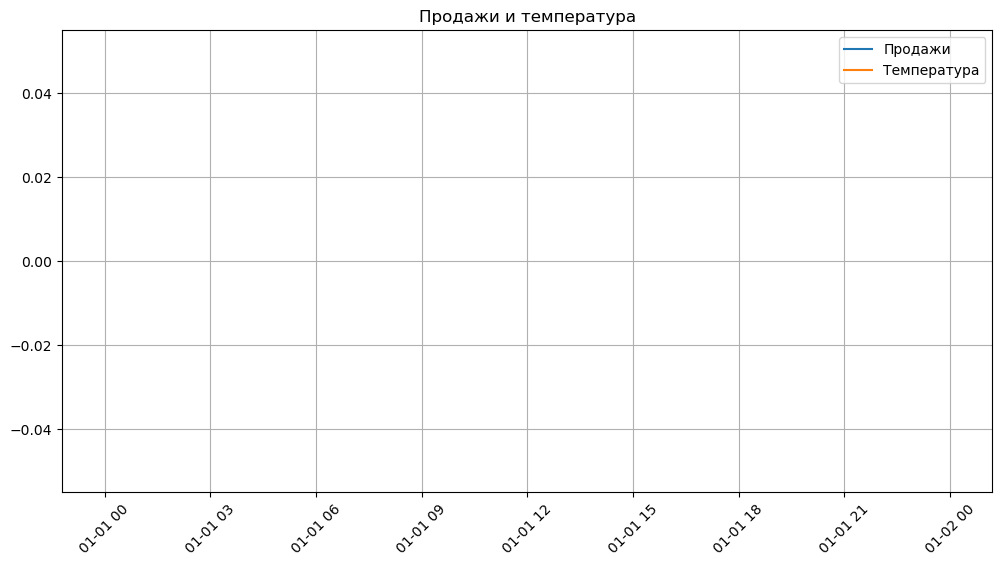

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(merged_df["Дата"], merged_df["Количество продаж"], label="Продажи")
plt.plot(merged_df["Дата"], merged_df["T"], label="Температура")

plt.legend()
plt.title("Продажи и температура")
plt.xticks(rotation=45)
plt.grid()
plt.show()

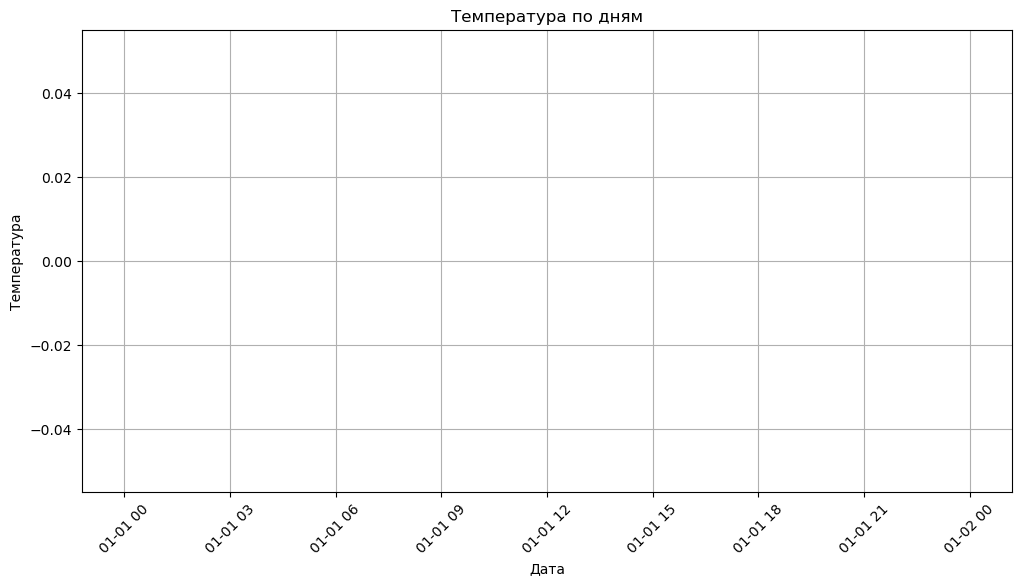

In [86]:
plt.figure(figsize=(12,6))

plt.plot(merged_df["Дата"], merged_df["T"], color="orange")

plt.title("Температура по дням")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [105]:
weather_df = weather_df.rename(
    columns={"Местное время в Астане": "Дата"}
)

In [106]:
weather_df["Дата"] = pd.to_datetime(
    weather_df["Дата"]
).dt.date

KeyError: 'Дата'

In [ ]:
в файле переименовала столбец на Дата, но все равно выходят ошибки, не сумела разобраться и исправить